In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter

In [2]:
gis = pd.read_csv("2gis_pansionaty_with_reviews.csv")
book = pd.read_csv("book_pansionaty.csv")
yandex = pd.read_csv("yandex_pansionaty.csv")

In [10]:
book["min_price_per_day"] = pd.to_numeric(book["min_price_per_day"], errors="coerce")
def extract_min_price(s):
    if pd.isna(s):
        return None
    nums = re.findall(r':\s*(\d+)', str(s))
    if not nums:
        return None
    val = min(int(x) for x in nums)
    return val if val >= 500 else None  

yandex["min_price"] = yandex["цены"].apply(extract_min_price)
yandex["тип"] = yandex["кол-во по сети"].apply(lambda x: "Сеть" if x > 1 else "Одиночный")

In [11]:
summary = pd.DataFrame({
    "Источник":         ["2GIS", "Яндекс", "BookPansion"],
    "Объектов":         [len(gis), len(yandex), len(book)],
    "Средний рейтинг":  [
        round(gis["рейтинг"].mean(), 2),
        round(yandex["рейтинг"].mean(), 2),
        round(book["rating"].mean(), 2)
    ],
    "Среднее отзывов":  [
        round(gis["число_отзывов"].mean(), 1),
        round(yandex["число отзывов"].mean(), 1),
        round(book["reviews"].mean(), 1)
    ],
})
summary

,Источник,Объектов,Средний рейтинг,Среднее отзывов
0,2GIS,46,3.95,56.4
1,Яндекс,92,3.46,30.8
2,BookPansion,15,4.71,12.5


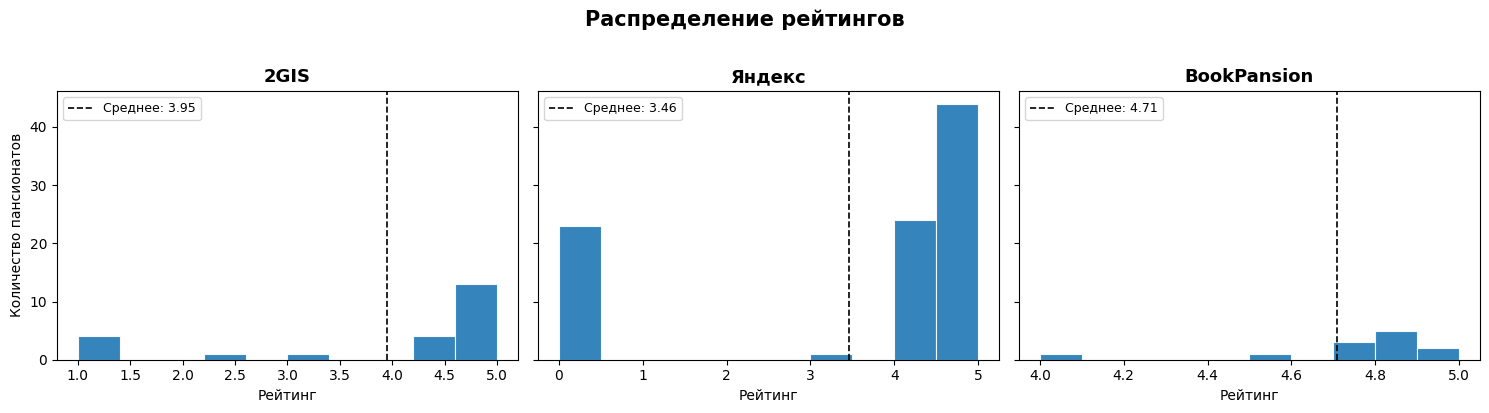

Вывод: рейтинги в BookPansion выше и сосредоточены у 4.7–5.0 — агрегатор отбирает только лучших.
Яндекс показывает реальный рынок с бимодальным распределением: много как высоких, так и низких оценок.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
datasets = [
    (gis["рейтинг"].dropna(),       "2GIS"),
    (yandex["рейтинг"].dropna(),    "Яндекс"),
    (book["rating"].dropna(),        "BookPansion"),
]

for ax, (data, title) in zip(axes, datasets):
    ax.hist(data, bins=10, edgecolor="white", linewidth=0.8, alpha=0.9)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2, label=f"Среднее: {data.mean():.2f}")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Рейтинг")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Количество пансионатов")
fig.suptitle("Распределение рейтингов", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot1_rating_distribution.png", bbox_inches="tight")
plt.show()

print("Вывод: рейтинги в BookPansion выше и сосредоточены у 4.7–5.0 — агрегатор отбирает только лучших.")
print("Яндекс показывает реальный рынок с бимодальным распределением: много как высоких, так и низких оценок.")

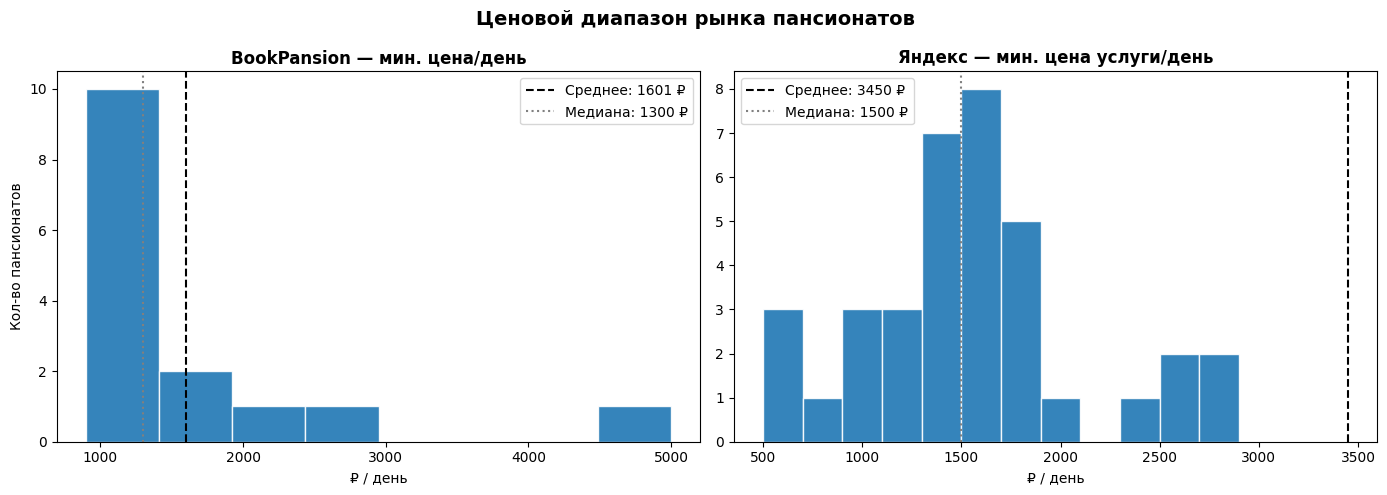

Медианная минимальная цена по BookPansion: 1300 ₽/день
Медианная цена по Яндексу: 1500 ₽/день


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BookPansion — точечно
book_p = book["min_price_per_day"].dropna()
axes[0].hist(book_p, bins=8, edgecolor="white", alpha=0.9)
axes[0].axvline(book_p.mean(), linestyle="--", color="black", label=f"Среднее: {book_p.mean():.0f} ₽")
axes[0].axvline(book_p.median(), linestyle=":", color="gray", label=f"Медиана: {book_p.median():.0f} ₽")
axes[0].set_title("BookPansion — мин. цена/день", fontsize=12, fontweight="bold")
axes[0].set_xlabel("₽ / день")
axes[0].set_ylabel("Кол-во пансионатов")
axes[0].legend()

# Яндекс — min price parsed
yan_p = yandex["min_price"].dropna()
axes[1].hist(yan_p[yan_p <= 5000], bins=12, edgecolor="white", alpha=0.9)
axes[1].axvline(yan_p.mean(), linestyle="--", color="black", label=f"Среднее: {yan_p.mean():.0f} ₽")
axes[1].axvline(yan_p.median(), linestyle=":", color="gray", label=f"Медиана: {yan_p.median():.0f} ₽")
axes[1].set_title("Яндекс — мин. цена услуги/день", fontsize=12, fontweight="bold")
axes[1].set_xlabel("₽ / день")
axes[1].legend()

fig.suptitle("Ценовой диапазон рынка пансионатов", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot5_prices.png", bbox_inches="tight")
plt.show()

print(f"Медианная минимальная цена по BookPansion: {book_p.median():.0f} ₽/день")
print(f"Медианная цена по Яндексу: {yan_p.median():.0f} ₽/день")

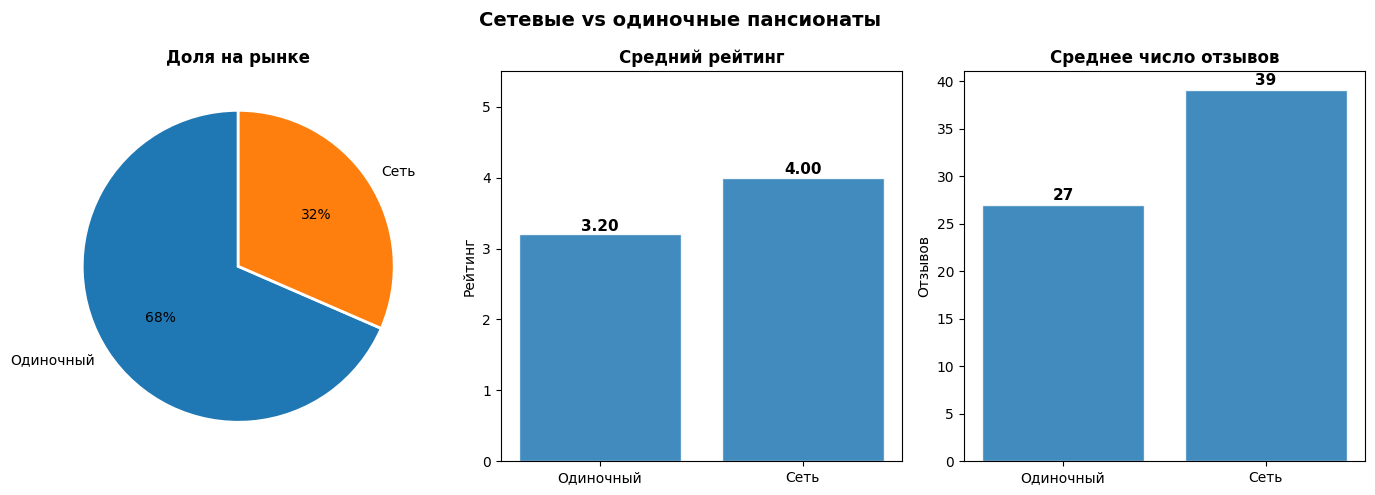

Вывод: сетевые пансионаты собирают больше отзывов (выше узнаваемость),
но средний рейтинг у одиночных часто не ниже — качество не зависит от масштаба.


In [24]:
network_counts = yandex["тип"].value_counts()
avg_rating = yandex.groupby("тип")["рейтинг"].mean()
avg_reviews = yandex.groupby("тип")["число отзывов"].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Pie
axes[0].pie(network_counts.values, labels=network_counts.index, autopct="%1.0f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Доля на рынке", fontsize=12, fontweight="bold")

# Avg rating
axes[1].bar(avg_rating.index, avg_rating.values, alpha=0.85, edgecolor="white")
for i, v in enumerate(avg_rating.values):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Средний рейтинг", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Рейтинг")
axes[1].set_ylim(0, 5.5)

# Avg reviews
axes[2].bar(avg_reviews.index, avg_reviews.values, alpha=0.85, edgecolor="white")
for i, v in enumerate(avg_reviews.values):
    axes[2].text(i, v + 0.5, f"{v:.0f}", ha="center", fontsize=11, fontweight="bold")
axes[2].set_title("Среднее число отзывов", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Отзывов")

fig.suptitle("Сетевые vs одиночные пансионаты", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot7_network_vs_solo.png", bbox_inches="tight")
plt.show()

print("Вывод: сетевые пансионаты собирают больше отзывов (выше узнаваемость),")
print("но средний рейтинг у одиночных часто не ниже — качество не зависит от масштаба.")